# Next-12h Hospital Deterioration Early-Warning Baseline

A practical notebook for validating the simulated hospital deterioration dataset, exploring early-warning signals, and training a leak-aware baseline model for next-12h deterioration prediction.

## Overview and goals

This notebook focuses on practical early-warning questions:

- Is the dataset structurally consistent and suitable for early-warning modeling?
- How common are deterioration events, and where does class imbalance appear?
- Which clinical signals move before deterioration?
- Can a simple, reproducible baseline rank high-risk hourly observations well enough to support an alert-policy discussion?

Important context: this dataset is simulated and intended for education, experimentation, and portfolio work. It must not be used for clinical decision-making.

In [1]:
from pathlib import Path
import os

os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".mplconfig"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_SEED = 42
TARGET = "deterioration_next_12h"

PRIMARY_COLOR = "#2563EB"
SECONDARY_COLOR = "#F97316"
DANGER_COLOR = "#DC2626"
SUCCESS_COLOR = "#16A34A"
NEUTRAL_COLOR = "#64748B"
GRID_COLOR = "#E5E7EB"

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", "{:,.4f}".format)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.grid": True,
    "grid.color": GRID_COLOR,
    "grid.alpha": 0.7,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.frameon": False,
})

## Data loading

The path resolver below supports both Kaggle input folders and local repository-style layouts. It searches for the required dataset files without hard-coding a single Kaggle dataset slug.

In [2]:
REQUIRED_FILES = [
    "patients.csv",
    "vitals_timeseries.csv",
    "labs_timeseries.csv",
    "hospital_deterioration_hourly_panel.csv",
    "hospital_deterioration_ml_ready.csv",
]

def find_data_dir(required_files=REQUIRED_FILES):
    candidate_roots = []

    env_data_dir = os.environ.get("DATA_DIR")
    if env_data_dir:
        candidate_roots.append(Path(env_data_dir))

    candidate_roots.extend([
        Path("/kaggle/input"),
        Path("data/raw"),
        Path("."),
    ])

    checked_roots = []
    for root in candidate_roots:
        root = root.expanduser().resolve() if root.exists() else root
        if not root.exists():
            continue

        checked_roots.append(str(root))

        if all((root / file_name).exists() for file_name in required_files):
            return root

        for first_file in root.rglob(required_files[0]):
            candidate = first_file.parent
            if all((candidate / file_name).exists() for file_name in required_files):
                return candidate

    raise FileNotFoundError(
        "Could not find the dataset files. Checked roots: "
        + ", ".join(checked_roots)
    )

DATA_DIR = find_data_dir()
print(f"Data directory: {DATA_DIR}")

patients = pd.read_csv(DATA_DIR / "patients.csv")
vitals = pd.read_csv(DATA_DIR / "vitals_timeseries.csv")
labs = pd.read_csv(DATA_DIR / "labs_timeseries.csv")
panel = pd.read_csv(DATA_DIR / "hospital_deterioration_hourly_panel.csv")
ml_ready = pd.read_csv(DATA_DIR / "hospital_deterioration_ml_ready.csv")

tables = {
    "patients": patients,
    "vitals": vitals,
    "labs": labs,
    "panel": panel,
    "ml_ready": ml_ready,
}

shape_summary = pd.DataFrame(
    [
        {
            "table": name,
            "rows": df.shape[0],
            "columns": df.shape[1],
            "missing_values": int(df.isna().sum().sum()),
            "duplicate_rows": int(df.duplicated().sum()),
        }
        for name, df in tables.items()
    ]
)

display(shape_summary)
display(panel.head(3))

Data directory: /kaggle/input/hospital-deterioration-dataset


,table,rows,columns,missing_values,duplicate_rows
0,patients,10000,10,0,0
1,vitals,417866,12,0,0
2,labs,417866,8,0,0
3,panel,417866,28,0,0
4,ml_ready,417866,22,0,0


,patient_id,hour_from_admission,heart_rate,respiratory_rate,spo2_pct,temperature_c,systolic_bp,diastolic_bp,oxygen_device,oxygen_flow,mobility_score,nurse_alert,wbc_count,lactate,creatinine,crp_level,hemoglobin,sepsis_risk_score,age,gender,comorbidity_index,admission_type,baseline_risk_score,los_hours,deterioration_event,deterioration_within_12h_from_admission,deterioration_hour,deterioration_next_12h
0,1,0,68.5800,14.4700,96.5200,37.1800,108.9400,78.4300,none,0.0000,2,0,5.6800,1.2800,1.2700,10.6600,13.5500,0.2621,24,M,2,Elective,0.2173,17,0,0,-1,0
1,1,1,67.0300,13.8700,94.9400,37.2500,111.7300,79.1400,none,0.0000,3,0,5.4600,1.1800,1.2200,11.9400,13.6500,0.3353,24,M,2,Elective,0.2173,17,0,0,-1,0
2,1,2,69.0500,14.6300,94.4500,37.2900,111.4800,78.8600,none,0.0000,2,0,5.5500,1.2100,1.2500,10.2400,13.6900,0.1678,24,M,2,Elective,0.2173,17,0,0,-1,0


## Basic table information

The joined hourly panel is the main analysis table. The ML-ready file is useful, but the joined panel keeps `patient_id`, which is required for patient-level splitting.

In [3]:
panel.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 417866 entries, 0 to 417865
Data columns (total 28 columns):
 #   Column                                   Non-Null Count   Dtype  
---  ------                                   --------------   -----  
 0   patient_id                               417866 non-null  int64  
 1   hour_from_admission                      417866 non-null  int64  
 2   heart_rate                               417866 non-null  float64
 3   respiratory_rate                         417866 non-null  float64
 4   spo2_pct                                 417866 non-null  float64
 5   temperature_c                            417866 non-null  float64
 6   systolic_bp                              417866 non-null  float64
 7   diastolic_bp                             417866 non-null  float64
 8   oxygen_device                            417866 non-null  object 
 9   oxygen_flow                              417866 non-null  float64
 10  mobility_score                  

## Dataset integrity checks

These checks verify the most important structural assumptions before any modeling:

- patient identifiers are aligned across files,
- hourly keys are unique,
- panel row count matches total length of stay,
- the next-12h label matches the documented definition,
- oxygen-flow logic is inspected in both directions.

In [4]:
def yes_no(value):
    return "PASS" if bool(value) else "CHECK"

def check_key_uniqueness(df, keys):
    return int(df.duplicated(keys).sum())

patient_ids = set(patients["patient_id"])
panel_patient_ids = set(panel["patient_id"])
vitals_patient_ids = set(vitals["patient_id"])
labs_patient_ids = set(labs["patient_id"])

recomputed_next_12h = (
    panel["deterioration_hour"].ne(-1)
    & panel["hour_from_admission"].lt(panel["deterioration_hour"])
    & panel["deterioration_hour"].le(panel["hour_from_admission"] + 12)
).astype(int)

oxygen_none_positive = int(
    ((vitals["oxygen_device"] == "none") & (vitals["oxygen_flow"] > 0)).sum()
)

oxygen_device_zero_flow = int(
    ((vitals["oxygen_device"] != "none") & (vitals["oxygen_flow"] <= 0)).sum()
)

integrity_checks = pd.DataFrame(
    [
        {
            "check": "patients.csv has one row per patient",
            "result": yes_no(patients["patient_id"].is_unique),
            "value": int(patients["patient_id"].nunique()),
        },
        {
            "check": "vitals key uniqueness",
            "result": yes_no(check_key_uniqueness(vitals, ["patient_id", "hour_from_admission"]) == 0),
            "value": check_key_uniqueness(vitals, ["patient_id", "hour_from_admission"]),
        },
        {
            "check": "labs key uniqueness",
            "result": yes_no(check_key_uniqueness(labs, ["patient_id", "hour_from_admission"]) == 0),
            "value": check_key_uniqueness(labs, ["patient_id", "hour_from_admission"]),
        },
        {
            "check": "panel key uniqueness",
            "result": yes_no(check_key_uniqueness(panel, ["patient_id", "hour_from_admission"]) == 0),
            "value": check_key_uniqueness(panel, ["patient_id", "hour_from_admission"]),
        },
        {
            "check": "panel row count equals total length of stay",
            "result": yes_no(len(panel) == int(patients["los_hours"].sum())),
            "value": f"{len(panel):,} / {int(patients['los_hours'].sum()):,}",
        },
        {
            "check": "patient IDs aligned across joined tables",
            "result": yes_no(patient_ids == panel_patient_ids == vitals_patient_ids == labs_patient_ids),
            "value": len(patient_ids),
        },
        {
            "check": "hour_from_admission is inside length of stay",
            "result": yes_no((panel["hour_from_admission"] < panel["los_hours"]).all()),
            "value": int((panel["hour_from_admission"] >= panel["los_hours"]).sum()),
        },
        {
            "check": "next-12h target matches documented definition",
            "result": yes_no((recomputed_next_12h == panel[TARGET]).all()),
            "value": int((recomputed_next_12h != panel[TARGET]).sum()),
        },
        {
            "check": "oxygen_device == none has zero oxygen_flow",
            "result": yes_no(oxygen_none_positive == 0),
            "value": oxygen_none_positive,
        },
        {
            "check": "oxygen_device != none has positive oxygen_flow",
            "result": "CHECK" if oxygen_device_zero_flow > 0 else "PASS",
            "value": oxygen_device_zero_flow,
        },
    ]
)

display(integrity_checks)

,check,result,value
0,patients.csv has one row per patient,PASS,10000
1,vitals key uniqueness,PASS,0
2,labs key uniqueness,PASS,0
3,panel key uniqueness,PASS,0
4,panel row count equals total length of stay,PASS,"417,866 / 417,866"
5,patient IDs aligned across joined tables,PASS,10000
6,hour_from_admission is inside length of stay,PASS,0
7,next-12h target matches documented definition,PASS,0
8,oxygen_device == none has zero oxygen_flow,PASS,0
9,oxygen_device != none has positive oxygen_flow,CHECK,1655


The oxygen-flow check is intentionally shown in both directions. Rows with an oxygen device and zero flow should be treated as a minor documentation or simulation edge case, not as a modeling blocker, because the categorical device variable still carries the device state.

## Cohort and target profile

,metric,value
0,Patients,"10,000"
1,Hourly observations,"417,866"
2,Any deterioration event patients,"1,938"
3,Any deterioration event rate,19.38%
4,Positive next-12h rows,"22,589"
5,Positive next-12h row rate,5.41%
6,Median length of stay hours,42
7,Maximum length of stay hours,72


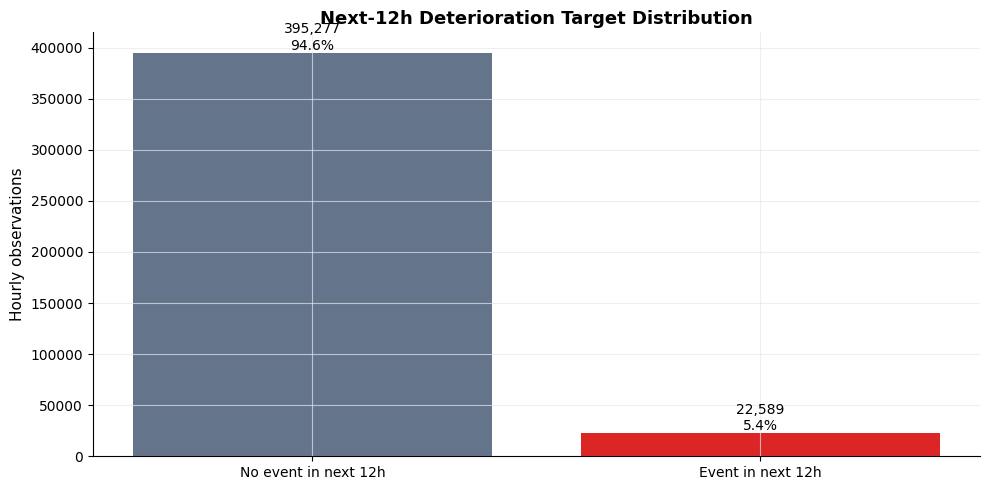

In [5]:
cohort_summary = pd.DataFrame(
    {
        "metric": [
            "Patients",
            "Hourly observations",
            "Any deterioration event patients",
            "Any deterioration event rate",
            "Positive next-12h rows",
            "Positive next-12h row rate",
            "Median length of stay hours",
            "Maximum length of stay hours",
        ],
        "value": [
            f"{patients.shape[0]:,}",
            f"{panel.shape[0]:,}",
            f"{patients['deterioration_event'].sum():,}",
            f"{patients['deterioration_event'].mean():.2%}",
            f"{panel[TARGET].sum():,}",
            f"{panel[TARGET].mean():.2%}",
            f"{patients['los_hours'].median():.0f}",
            f"{patients['los_hours'].max():.0f}",
        ],
    }
)

display(cohort_summary)

target_counts = panel[TARGET].value_counts().sort_index()
fig, ax = plt.subplots()
ax.bar(["No event in next 12h", "Event in next 12h"], target_counts.values, color=[NEUTRAL_COLOR, DANGER_COLOR])
ax.set_title("Next-12h Deterioration Target Distribution")
ax.set_ylabel("Hourly observations")
for idx, value in enumerate(target_counts.values):
    ax.text(idx, value, f"{value:,}\n{value / len(panel):.1%}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

Caption: The row-level target is strongly imbalanced. A useful early-warning baseline should be judged with precision-recall metrics and alert-burden tradeoffs, not accuracy alone.

## Patient-level deterioration timing

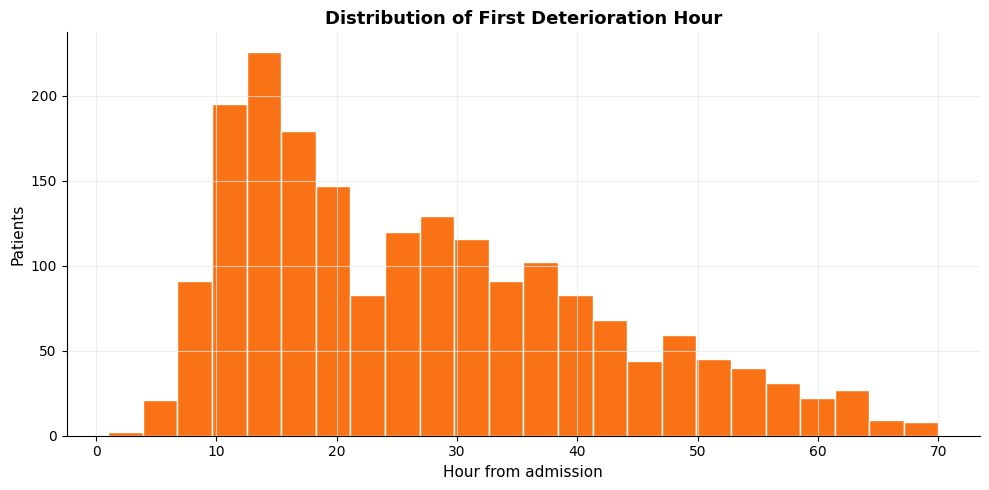

,deterioration_hour
count,"1,938.0000"
mean,27.1006
std,14.6384
min,1.0000
10%,11.0000
25%,15.0000
50%,24.0000
75%,37.0000
90%,49.0000
max,70.0000


In [6]:
event_patients = patients.query("deterioration_event == 1").copy()

fig, ax = plt.subplots()
ax.hist(event_patients["deterioration_hour"], bins=24, color=SECONDARY_COLOR, edgecolor="white")
ax.set_title("Distribution of First Deterioration Hour")
ax.set_xlabel("Hour from admission")
ax.set_ylabel("Patients")
plt.tight_layout()
plt.show()

display(
    event_patients["deterioration_hour"]
    .describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
    .to_frame("deterioration_hour")
)

Caption: Deterioration timing is spread across the admission window, which makes an hourly next-12h formulation more useful than a single admission-level label.

## Baseline risk score calibration check

`baseline_risk_score` is a latent simulation score at admission. It is useful for dataset sanity checks, but the model below does not use it as a feature.

,risk_decile,patients,mean_baseline_risk,observed_event_rate
0,1,1000,0.1572,0.0990
1,2,1000,0.2563,0.1320
2,3,1000,0.3274,0.1450
3,4,1000,0.3984,0.1810
4,5,1000,0.4648,0.1930
5,6,1001,0.5318,0.1958
6,7,1000,0.6011,0.2090
7,8,999,0.6711,0.2192
8,9,1001,0.7479,0.2687
9,10,999,0.8434,0.2953


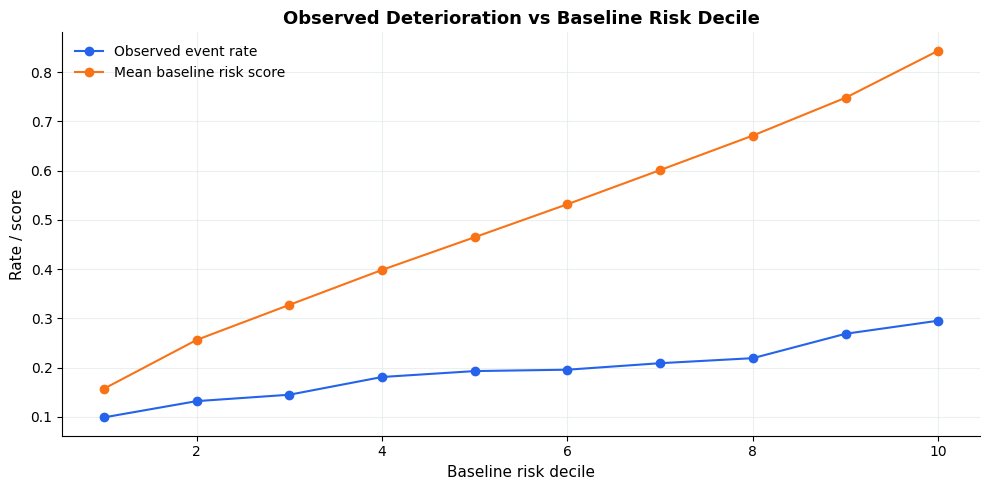

In [7]:
risk_df = patients.copy()
risk_df["risk_decile"] = pd.qcut(
    risk_df["baseline_risk_score"],
    q=10,
    labels=False,
    duplicates="drop",
) + 1

risk_by_decile = (
    risk_df.groupby("risk_decile", as_index=False)
    .agg(
        patients=("patient_id", "count"),
        mean_baseline_risk=("baseline_risk_score", "mean"),
        observed_event_rate=("deterioration_event", "mean"),
    )
)

display(risk_by_decile)

fig, ax = plt.subplots()
ax.plot(
    risk_by_decile["risk_decile"],
    risk_by_decile["observed_event_rate"],
    marker="o",
    color=PRIMARY_COLOR,
    label="Observed event rate",
)
ax.plot(
    risk_by_decile["risk_decile"],
    risk_by_decile["mean_baseline_risk"],
    marker="o",
    color=SECONDARY_COLOR,
    label="Mean baseline risk score",
)
ax.set_title("Observed Deterioration vs Baseline Risk Decile")
ax.set_xlabel("Baseline risk decile")
ax.set_ylabel("Rate / score")
ax.legend()
plt.tight_layout()
plt.show()

Caption: Higher latent baseline risk deciles show higher observed deterioration rates, which supports the simulation's internal consistency. The predictive model remains stricter by excluding this latent score.

## Signal patterns over admission time

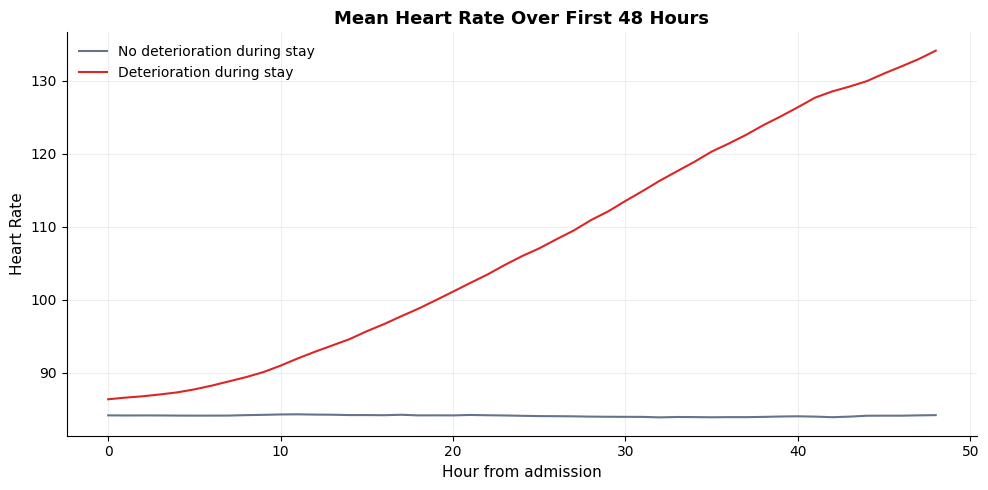

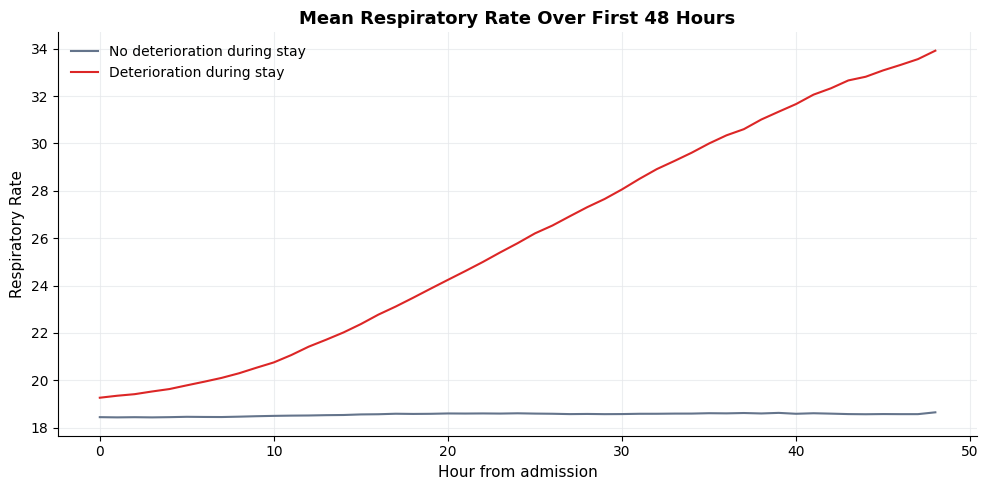

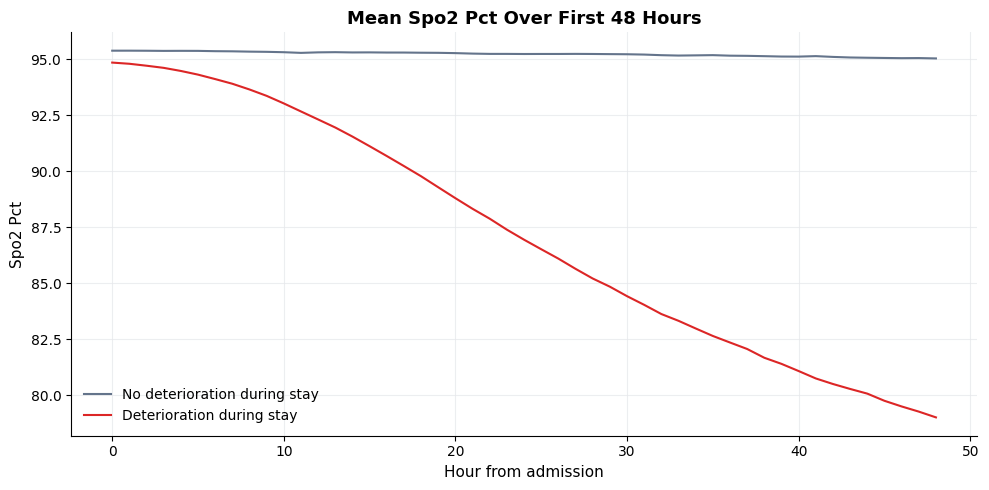

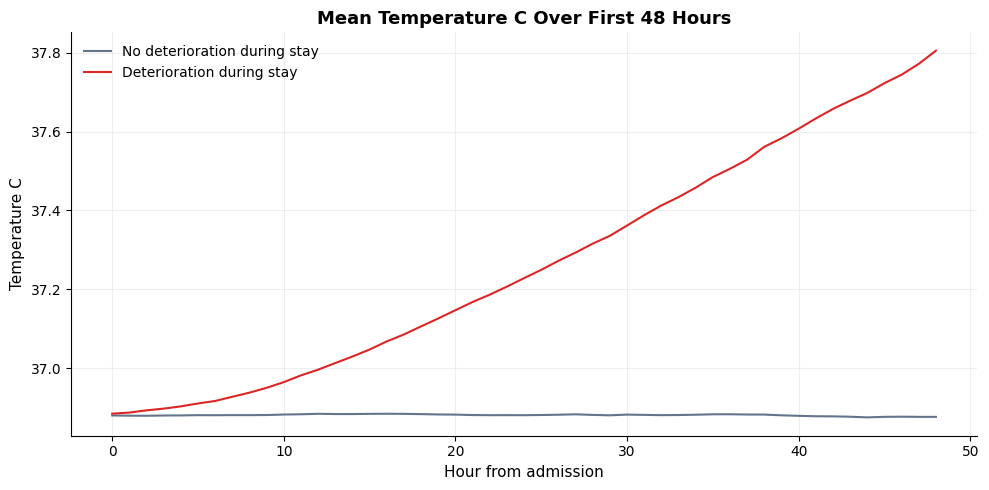

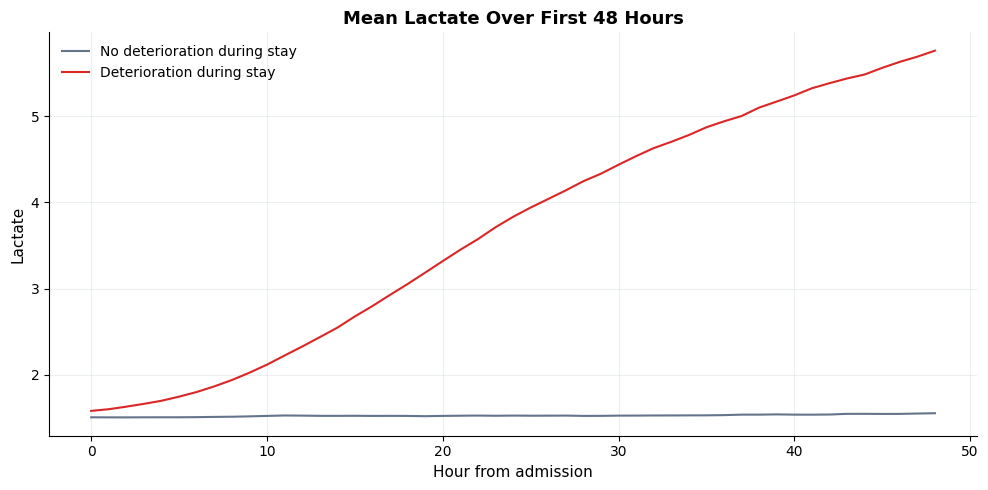

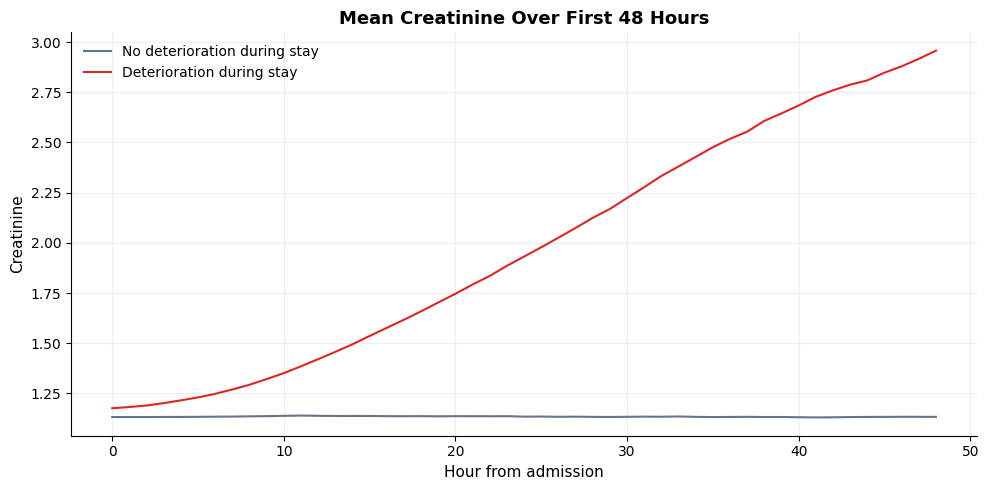

In [8]:
trajectory_features = [
    "heart_rate",
    "respiratory_rate",
    "spo2_pct",
    "temperature_c",
    "lactate",
    "creatinine",
]

hourly_by_event = (
    panel.loc[panel["hour_from_admission"] <= 48]
    .groupby(["hour_from_admission", "deterioration_event"], as_index=False)[trajectory_features]
    .mean()
)

for feature in trajectory_features:
    fig, ax = plt.subplots()
    for event_value, color, label in [
        (0, NEUTRAL_COLOR, "No deterioration during stay"),
        (1, DANGER_COLOR, "Deterioration during stay"),
    ]:
        subset = hourly_by_event[hourly_by_event["deterioration_event"] == event_value]
        ax.plot(subset["hour_from_admission"], subset[feature], color=color, label=label)

    ax.set_title(f"Mean {feature.replace('_', ' ').title()} Over First 48 Hours")
    ax.set_xlabel("Hour from admission")
    ax.set_ylabel(feature.replace("_", " ").title())
    ax.legend()
    plt.tight_layout()
    plt.show()

Caption: The event group shows systematically higher physiologic stress across several signals. These are cohort-level patterns, not causal claims.

## Pre-event trajectory view

This view aligns deteriorating patients by their first deterioration hour and looks backward up to 24 hours.

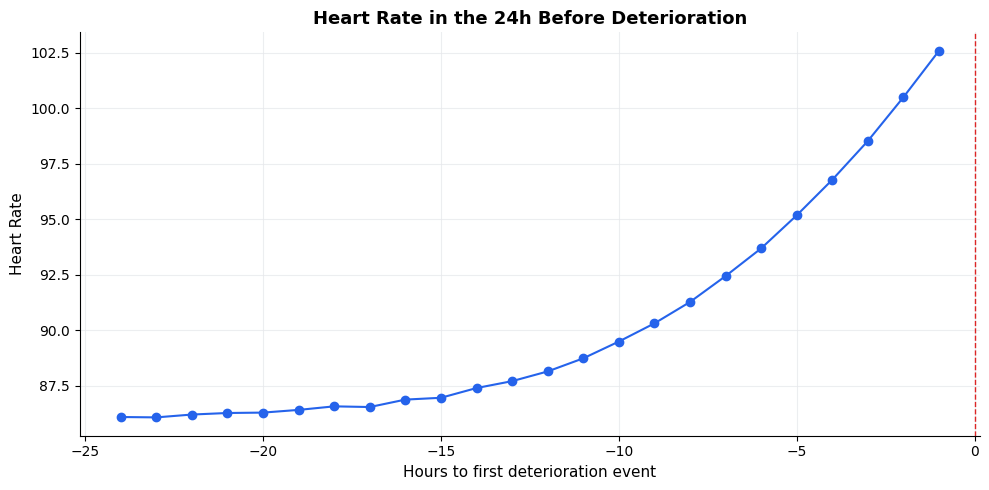

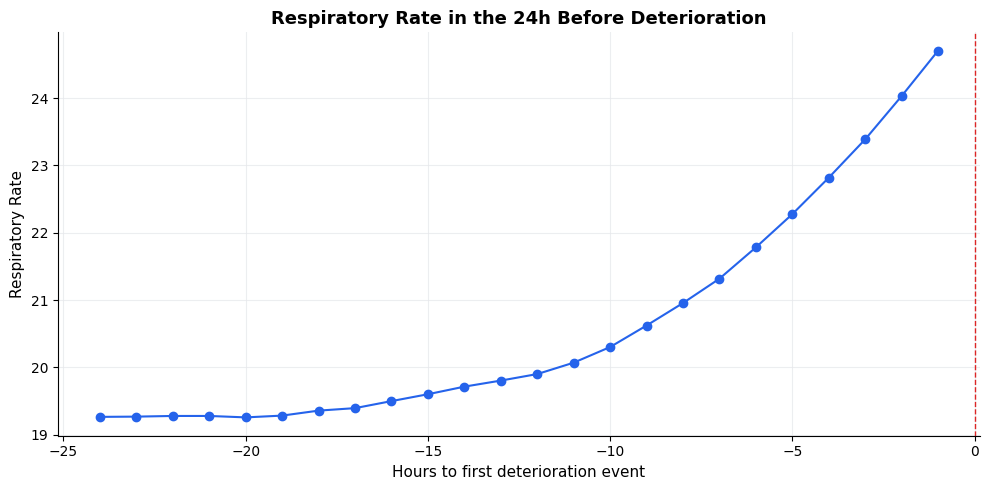

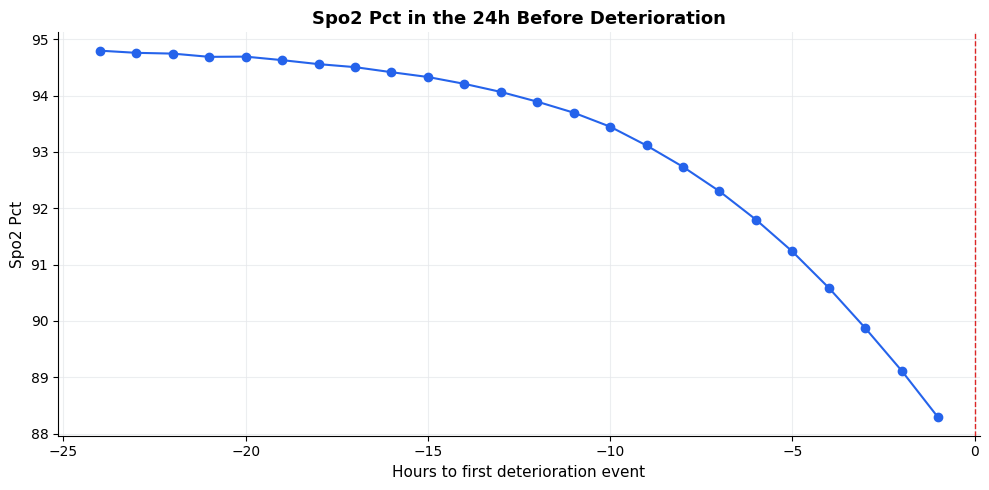

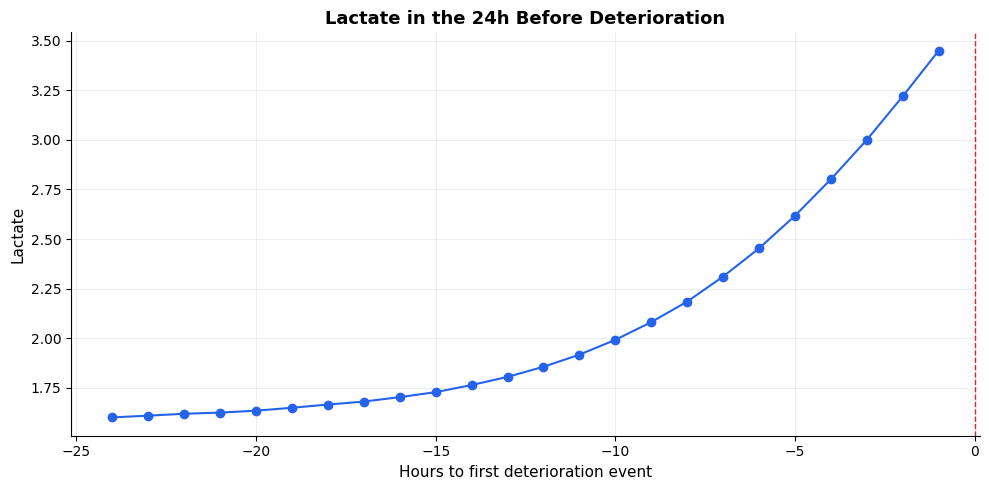

In [9]:
pre_event = panel.query("deterioration_event == 1").copy()
pre_event["hours_to_event"] = pre_event["hour_from_admission"] - pre_event["deterioration_hour"]
pre_event_window = pre_event.query("-24 <= hours_to_event <= -1").copy()

pre_event_features = ["heart_rate", "respiratory_rate", "spo2_pct", "lactate"]
pre_event_summary = (
    pre_event_window.groupby("hours_to_event", as_index=False)[pre_event_features]
    .mean()
    .sort_values("hours_to_event")
)

for feature in pre_event_features:
    fig, ax = plt.subplots()
    ax.plot(pre_event_summary["hours_to_event"], pre_event_summary[feature], marker="o", color=PRIMARY_COLOR)
    ax.axvline(0, color=DANGER_COLOR, linestyle="--", linewidth=1)
    ax.set_title(f"{feature.replace('_', ' ').title()} in the 24h Before Deterioration")
    ax.set_xlabel("Hours to first deterioration event")
    ax.set_ylabel(feature.replace("_", " ").title())
    plt.tight_layout()
    plt.show()

Caption: Aligned pre-event trajectories make the early-warning framing easier to inspect. They also help validate whether the target is learnable from recent observations.

## Modeling design

The baseline uses a patient-level split. This prevents the same patient from appearing in both training and evaluation rows.

Modeling choices:

- Target: `deterioration_next_12h`
- Primary metric: Average Precision, because the positive class is rare
- Secondary metric: ROC AUC
- Model: regularized logistic regression with preprocessing inside a scikit-learn pipeline
- Excluded from features: `patient_id`, future labels, event metadata, and latent `baseline_risk_score`

This is intentionally a baseline, not a final clinical model.

In [10]:
FEATURES = [
    "hour_from_admission",
    "heart_rate",
    "respiratory_rate",
    "spo2_pct",
    "temperature_c",
    "systolic_bp",
    "diastolic_bp",
    "oxygen_device",
    "oxygen_flow",
    "mobility_score",
    "nurse_alert",
    "wbc_count",
    "lactate",
    "creatinine",
    "crp_level",
    "hemoglobin",
    "sepsis_risk_score",
    "age",
    "gender",
    "comorbidity_index",
    "admission_type",
]

CATEGORICAL_FEATURES = ["oxygen_device", "gender", "admission_type"]
NUMERIC_FEATURES = [feature for feature in FEATURES if feature not in CATEGORICAL_FEATURES]

patient_split_frame = (
    panel.groupby("patient_id", as_index=False)[TARGET]
    .max()
    .rename(columns={TARGET: "patient_has_positive_window"})
)

train_patient_ids, temp_patient_ids = train_test_split(
    patient_split_frame["patient_id"],
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=patient_split_frame["patient_has_positive_window"],
)

temp_split_frame = patient_split_frame[
    patient_split_frame["patient_id"].isin(temp_patient_ids)
]

valid_patient_ids, test_patient_ids = train_test_split(
    temp_split_frame["patient_id"],
    test_size=0.50,
    random_state=RANDOM_SEED,
    stratify=temp_split_frame["patient_has_positive_window"],
)

train_df = panel[panel["patient_id"].isin(train_patient_ids)].copy()
valid_df = panel[panel["patient_id"].isin(valid_patient_ids)].copy()
test_df = panel[panel["patient_id"].isin(test_patient_ids)].copy()

split_summary = pd.DataFrame(
    [
        {
            "split": "train",
            "patients": train_df["patient_id"].nunique(),
            "rows": len(train_df),
            "positive_row_rate": train_df[TARGET].mean(),
        },
        {
            "split": "validation",
            "patients": valid_df["patient_id"].nunique(),
            "rows": len(valid_df),
            "positive_row_rate": valid_df[TARGET].mean(),
        },
        {
            "split": "test",
            "patients": test_df["patient_id"].nunique(),
            "rows": len(test_df),
            "positive_row_rate": test_df[TARGET].mean(),
        },
    ]
)

display(split_summary)

,split,patients,rows,positive_row_rate
0,train,7000,293350,0.0540
1,validation,1500,62609,0.0538
2,test,1500,61907,0.0546


In [11]:
def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", make_one_hot_encoder()),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, NUMERIC_FEATURES),
        ("categorical", categorical_pipeline, CATEGORICAL_FEATURES),
    ],
    remainder="drop",
)

baseline_model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        (
            "model",
            LogisticRegression(
                max_iter=500,
                class_weight="balanced",
                solver="liblinear",
                random_state=RANDOM_SEED,
            ),
        ),
    ]
)

baseline_model.fit(train_df[FEATURES], train_df[TARGET])

valid_proba = baseline_model.predict_proba(valid_df[FEATURES])[:, 1]
test_proba = baseline_model.predict_proba(test_df[FEATURES])[:, 1]

print("Baseline model fitted.")

Baseline model fitted.


## Ranking performance

,split,average_precision,roc_auc,positive_rate,mean_predicted_score
0,validation,0.2531,0.8099,0.0538,0.3604
1,test,0.2736,0.8132,0.0546,0.3649


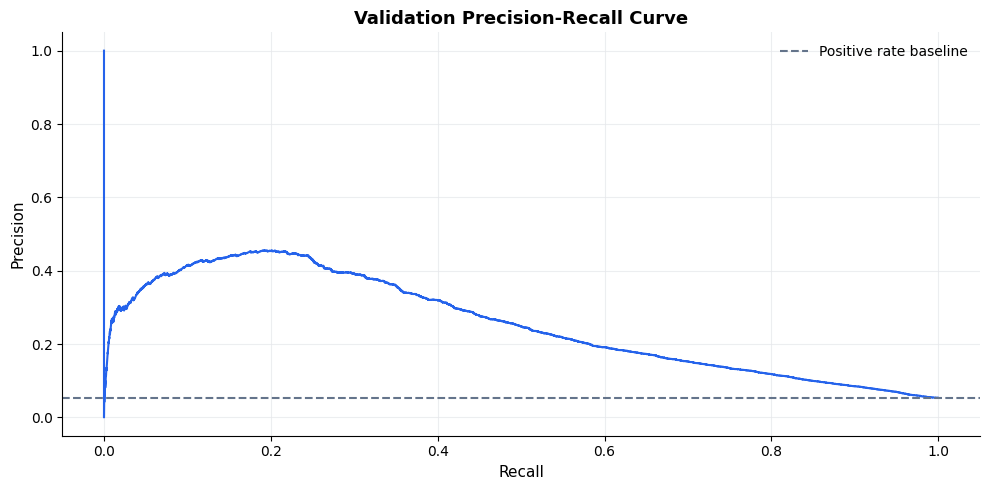

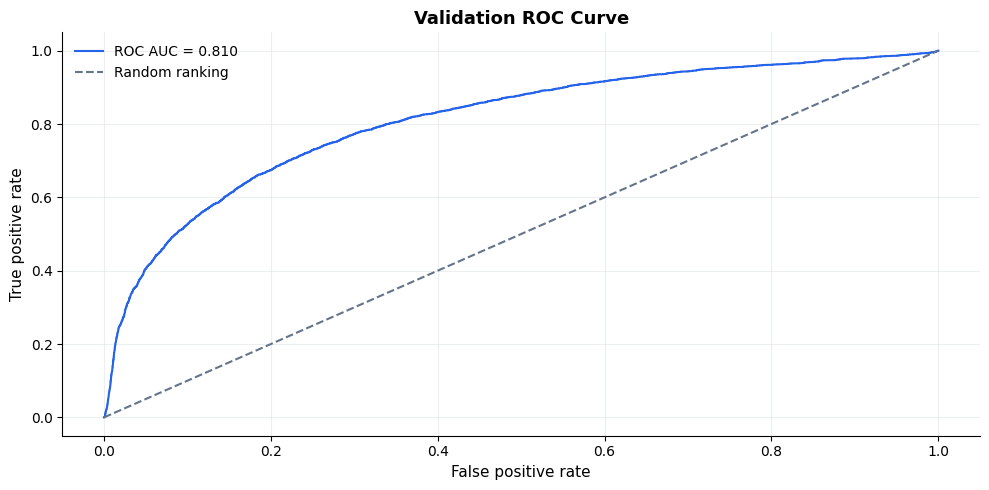

In [12]:
def ranking_metrics(y_true, proba):
    return {
        "average_precision": average_precision_score(y_true, proba),
        "roc_auc": roc_auc_score(y_true, proba),
        "positive_rate": np.mean(y_true),
        "mean_predicted_score": np.mean(proba),
    }

ranking_table = pd.DataFrame(
    [
        {"split": "validation", **ranking_metrics(valid_df[TARGET], valid_proba)},
        {"split": "test", **ranking_metrics(test_df[TARGET], test_proba)},
    ]
)

display(ranking_table)

precision, recall, pr_thresholds = precision_recall_curve(valid_df[TARGET], valid_proba)
fpr, tpr, roc_thresholds = roc_curve(valid_df[TARGET], valid_proba)

fig, ax = plt.subplots()
ax.plot(recall, precision, color=PRIMARY_COLOR)
ax.axhline(valid_df[TARGET].mean(), color=NEUTRAL_COLOR, linestyle="--", label="Positive rate baseline")
ax.set_title("Validation Precision-Recall Curve")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots()
ax.plot(fpr, tpr, color=PRIMARY_COLOR, label=f"ROC AUC = {roc_auc_score(valid_df[TARGET], valid_proba):.3f}")
ax.plot([0, 1], [0, 1], color=NEUTRAL_COLOR, linestyle="--", label="Random ranking")
ax.set_title("Validation ROC Curve")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.legend()
plt.tight_layout()
plt.show()

Caption: Average Precision is the key metric here because alerting is evaluated under class imbalance. ROC AUC is useful as a ranking check, but it can look optimistic when positives are rare.

## Alert-policy analysis

An early-warning model is only useful if the operating threshold is tied to review capacity. The table below evaluates thresholds chosen on the validation set and then reports their test-set behavior.

In [13]:
def metrics_at_threshold(y_true, proba, threshold):
    y_pred = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    precision_value = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall_value = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1_value = (
        2 * precision_value * recall_value / (precision_value + recall_value)
        if (precision_value + recall_value) > 0
        else 0.0
    )

    return {
        "threshold": threshold,
        "alert_rate": y_pred.mean(),
        "precision": precision_value,
        "recall": recall_value,
        "f1": f1_value,
        "true_positives": tp,
        "false_positives": fp,
        "false_negatives": fn,
        "true_negatives": tn,
    }

def threshold_for_top_alert_rate(proba, alert_rate):
    return float(np.quantile(proba, 1 - alert_rate))

def threshold_for_validation_precision(y_true, proba, min_precision):
    precision_values, recall_values, thresholds = precision_recall_curve(y_true, proba)
    candidate_indices = np.where(precision_values[:-1] >= min_precision)[0]

    if len(candidate_indices) == 0:
        return None

    best_index = candidate_indices[np.argmax(recall_values[:-1][candidate_indices])]
    return float(thresholds[best_index])

policy_thresholds = []

for alert_rate in [0.01, 0.03, 0.05, 0.10, 0.15]:
    policy_thresholds.append(
        {
            "policy": f"top_{int(alert_rate * 100)}pct_validation_scores",
            "threshold": threshold_for_top_alert_rate(valid_proba, alert_rate),
        }
    )

for min_precision in [0.20, 0.25, 0.30]:
    threshold = threshold_for_validation_precision(valid_df[TARGET].values, valid_proba, min_precision)
    if threshold is not None:
        policy_thresholds.append(
            {
                "policy": f"validation_precision_ge_{int(min_precision * 100)}pct",
                "threshold": threshold,
            }
        )

policy_thresholds.append({"policy": "default_0_50", "threshold": 0.50})

policy_rows = []

for item in policy_thresholds:
    valid_metrics = metrics_at_threshold(valid_df[TARGET].values, valid_proba, item["threshold"])
    test_metrics = metrics_at_threshold(test_df[TARGET].values, test_proba, item["threshold"])

    policy_rows.append(
        {
            "policy": item["policy"],
            "threshold": item["threshold"],
            "valid_alert_rate": valid_metrics["alert_rate"],
            "valid_precision": valid_metrics["precision"],
            "valid_recall": valid_metrics["recall"],
            "test_alert_rate": test_metrics["alert_rate"],
            "test_precision": test_metrics["precision"],
            "test_recall": test_metrics["recall"],
            "test_f1": test_metrics["f1"],
            "test_true_positives": test_metrics["true_positives"],
            "test_false_positives": test_metrics["false_positives"],
            "test_false_negatives": test_metrics["false_negatives"],
        }
    )

policy_table = pd.DataFrame(policy_rows).sort_values("threshold", ascending=False)
display(policy_table)

,policy,threshold,valid_alert_rate,valid_precision,valid_recall,test_alert_rate,test_precision,test_recall,test_f1,test_true_positives,test_false_positives,test_false_negatives
0,top_1pct_validation_scores,0.9477,0.0100,0.3907,0.0728,0.0095,0.4643,0.0807,0.1375,273,315,3109
1,top_3pct_validation_scores,0.8577,0.0300,0.4396,0.2453,0.0306,0.4613,0.2587,0.3315,875,1022,2507
2,top_5pct_validation_scores,0.7995,0.0500,0.3663,0.3407,0.0515,0.3789,0.3572,0.3677,1208,1980,2174
7,validation_precision_ge_30pct,0.7431,0.0752,0.3000,0.4197,0.0775,0.3026,0.4293,0.3550,1452,3347,1930
3,top_10pct_validation_scores,0.6982,0.1000,0.2592,0.4820,0.1033,0.2563,0.4846,0.3352,1639,4757,1743
6,validation_precision_ge_25pct,0.6860,0.1069,0.2500,0.4972,0.1111,0.2467,0.5018,0.3307,1697,5183,1685
4,top_15pct_validation_scores,0.6237,0.1500,0.2053,0.5726,0.1553,0.2048,0.5822,0.3030,1969,7647,1413
5,validation_precision_ge_20pct,0.6154,0.1566,0.2000,0.5824,0.1620,0.1994,0.5911,0.2982,1999,8027,1383
8,default_0_50,0.5000,0.2612,0.1471,0.7143,0.2681,0.1449,0.7108,0.2407,2404,14191,978


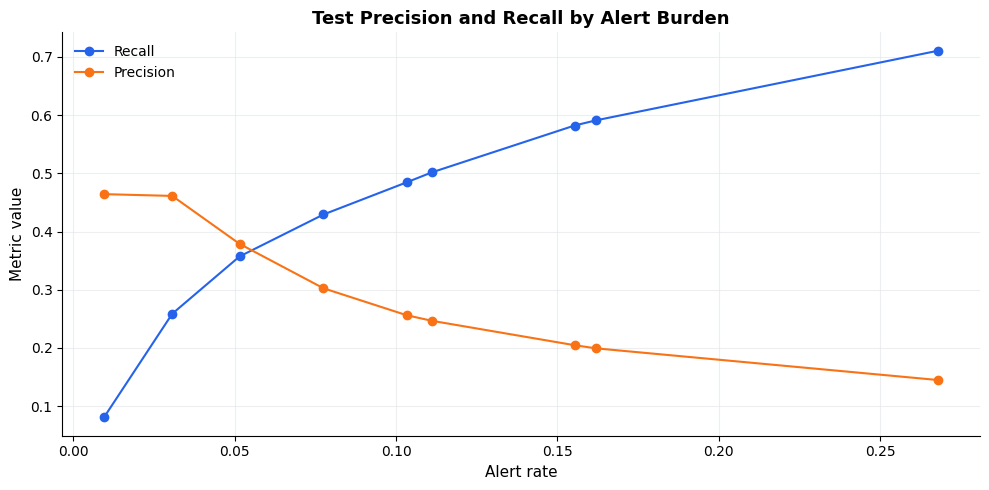

In [14]:
fig, ax = plt.subplots()
ax.plot(policy_table["test_alert_rate"], policy_table["test_recall"], marker="o", color=PRIMARY_COLOR, label="Recall")
ax.plot(policy_table["test_alert_rate"], policy_table["test_precision"], marker="o", color=SECONDARY_COLOR, label="Precision")
ax.set_title("Test Precision and Recall by Alert Burden")
ax.set_xlabel("Alert rate")
ax.set_ylabel("Metric value")
ax.legend()
plt.tight_layout()
plt.show()

Caption: Threshold selection is an operational decision. A low alert-rate policy reduces review burden but misses more events; a high recall policy triggers many more reviews.

## Coefficient inspection

The model is linear after preprocessing, so coefficient magnitudes provide a simple baseline interpretability view. These should be read as model diagnostics, not clinical effect estimates.

,feature,coefficient,abs_coefficient
21,oxygen_device_niv,-2.4847,2.4847
18,oxygen_device_hfnc,1.1219,1.1219
8,mobility_score,-0.7821,0.7821
19,oxygen_device_mask,0.7108,0.7108
15,sepsis_risk_score,0.6137,0.6137
20,oxygen_device_nasal,0.5785,0.5785
13,crp_level,-0.4068,0.4068
11,lactate,0.3841,0.3841
0,hour_from_admission,-0.3754,0.3754
3,spo2_pct,-0.3604,0.3604


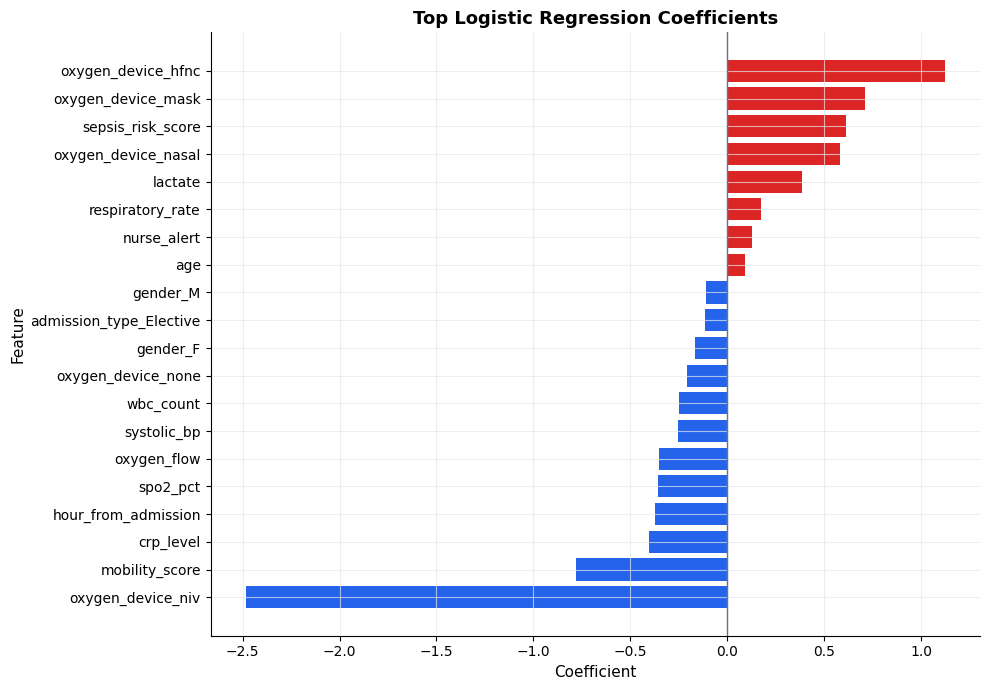

In [15]:
def get_feature_names_from_preprocessor(preprocessor):
    numeric_names = NUMERIC_FEATURES

    encoder = (
        preprocessor
        .named_transformers_["categorical"]
        .named_steps["encoder"]
    )

    categorical_names = list(
        encoder.get_feature_names_out(CATEGORICAL_FEATURES)
    )

    return numeric_names + categorical_names

feature_names = get_feature_names_from_preprocessor(
    baseline_model.named_steps["preprocess"]
)

coefficients = baseline_model.named_steps["model"].coef_[0]

coef_table = (
    pd.DataFrame(
        {
            "feature": feature_names,
            "coefficient": coefficients,
            "abs_coefficient": np.abs(coefficients),
        }
    )
    .sort_values("abs_coefficient", ascending=False)
    .head(20)
)

display(coef_table)

fig, ax = plt.subplots(figsize=(10, 7))
ordered = coef_table.sort_values("coefficient")
colors = [DANGER_COLOR if value > 0 else PRIMARY_COLOR for value in ordered["coefficient"]]
ax.barh(ordered["feature"], ordered["coefficient"], color=colors)
ax.axvline(0, color=NEUTRAL_COLOR, linewidth=1)
ax.set_title("Top Logistic Regression Coefficients")
ax.set_xlabel("Coefficient")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

Caption: The strongest coefficients are useful for sanity checking the baseline. They should be reviewed alongside domain logic and the known simulated nature of the data.

## Example patient trajectory

This example is included to make the hourly label easier to understand. It is not a case study of a real patient.

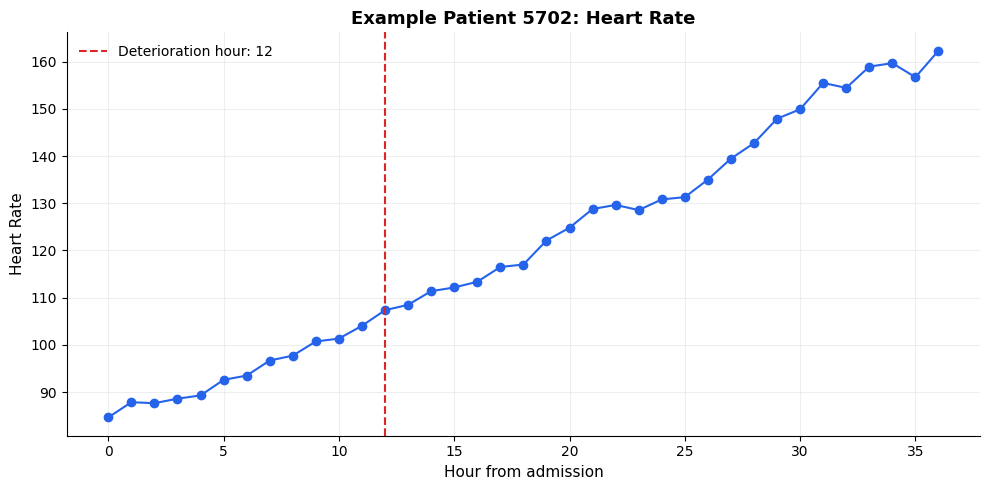

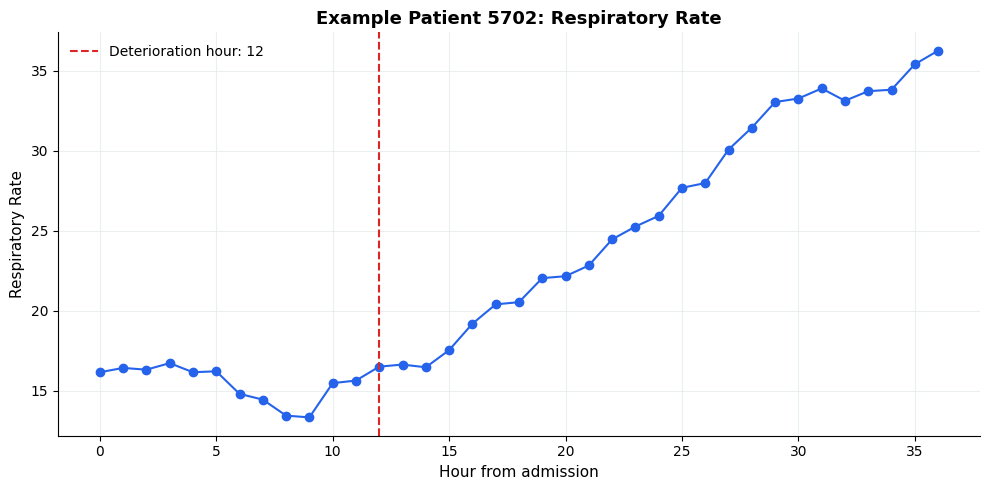

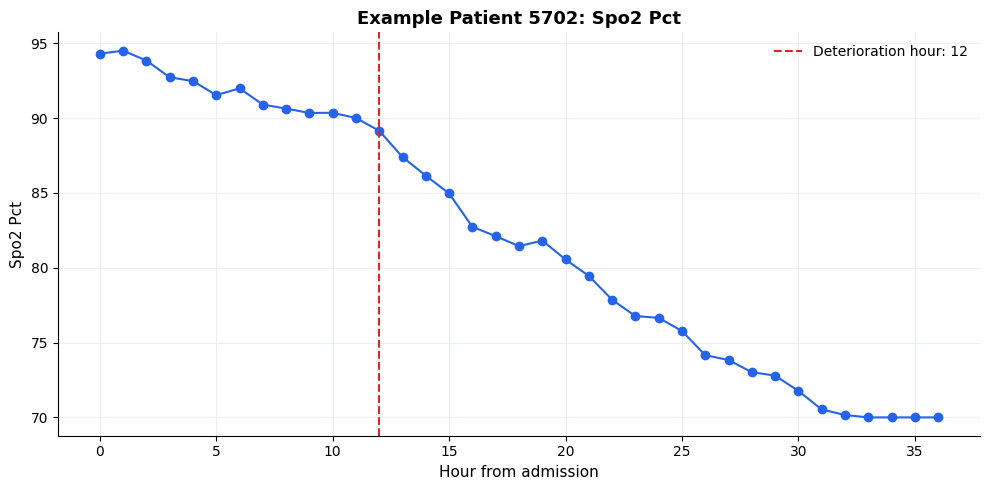

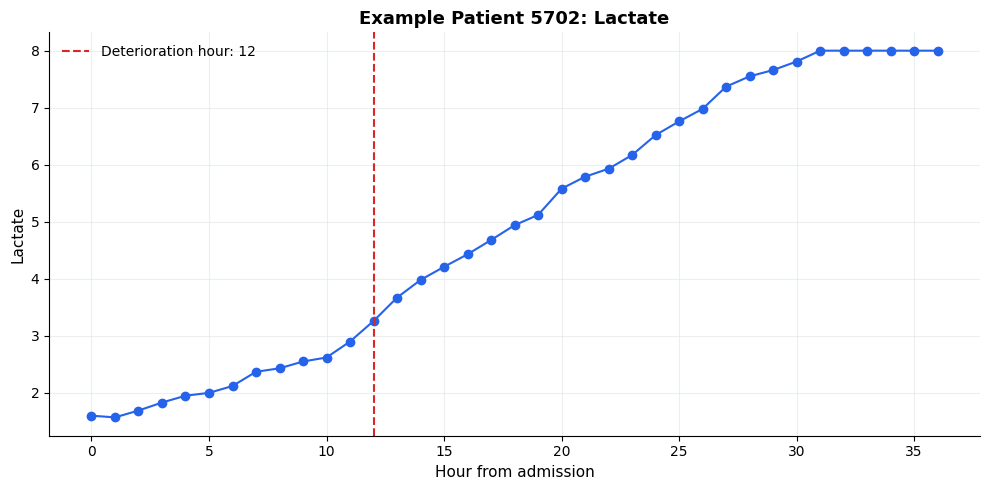

In [16]:
example_patient_id = (
    patients.query("deterioration_event == 1 and deterioration_hour >= 12")
    .sort_values("deterioration_hour")
    .iloc[0]["patient_id"]
)

example = panel[panel["patient_id"] == example_patient_id].copy()
event_hour = int(example["deterioration_hour"].iloc[0])

example_features = ["heart_rate", "respiratory_rate", "spo2_pct", "lactate"]

for feature in example_features:
    fig, ax = plt.subplots()
    ax.plot(example["hour_from_admission"], example[feature], marker="o", color=PRIMARY_COLOR)
    ax.axvline(event_hour, color=DANGER_COLOR, linestyle="--", label=f"Deterioration hour: {event_hour}")
    ax.set_title(f"Example Patient {int(example_patient_id)}: {feature.replace('_', ' ').title()}")
    ax.set_xlabel("Hour from admission")
    ax.set_ylabel(feature.replace("_", " ").title())
    ax.legend()
    plt.tight_layout()
    plt.show()

Caption: The next-12h label turns positive before the event hour, which is the behavior expected from an early-warning target.

## Decisions and takeaways

- The dataset is structurally usable: keys are unique, row counts align with length of stay, and the documented next-12h target is reproducible.
- The task is imbalanced at the hourly-row level, so Average Precision and threshold-policy analysis are more informative than accuracy.
- The baseline model is leak-aware because the split is patient-level and the feature set excludes identifiers, future labels, event metadata, and latent baseline risk.
- A simple logistic baseline already provides meaningful ranking signal, but it is not calibrated for clinical deployment.
- The oxygen-flow edge case should be documented in any dataset card or README because some rows have an oxygen device with zero flow.

## Recommended next steps

For a stronger follow-up notebook or production prototype:

- Add time-window feature engineering, such as rolling means, deltas, and volatility over the last 3 to 6 hours.
- Compare a tree-based model against the logistic baseline using the same patient-level split.
- Add calibration analysis before interpreting predicted probabilities.
- Evaluate patient-level alert burden, not only row-level alert burden.
- Package the final pipeline into a small batch scoring function or API endpoint.